In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Загрузка датасета
df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [15]:
# Количество строк и столбцов
f"Строк: {df.shape[0]}, столбцов: {df.shape[1]}"

'Строк: 891, столбцов: 12'

In [16]:
# Названия всех столбцов
df.columns.tolist()

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

In [17]:
# Типы данных столбцов
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Задание 3

In [18]:
# Количество пассажиров каждого класса
df['Pclass'].value_counts().sort_index()


Pclass
1    216
2    184
3    491
Name: count, dtype: int64

In [19]:
# Количество мужчин и женщин
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [20]:
# Разделение пассажиров на возрастные группы
bins = [0, 12, 18, 30, 50, 80]
labels = ['Дети (0–12)', 'Подростки (13–18)', 'Молодые (19–30)', 'Взрослые (31–50)', 'Пожилые (51+)']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

df['AgeGroup'].value_counts().sort_index()

AgeGroup
Дети (0–12)           69
Подростки (13–18)     70
Молодые (19–30)      270
Взрослые (31–50)     241
Пожилые (51+)         64
Name: count, dtype: int64

In [21]:
# Средний и медианный возраст, средняя стоимость билета
f"Средний возраст: {df['Age'].mean():.2f} лет"


'Средний возраст: 29.70 лет'

In [22]:
f"Медианный возраст: {df['Age'].median():.2f} лет"


'Медианный возраст: 28.00 лет'

In [23]:
f"Средняя стоимость билета: {df['Fare'].mean():.2f}"

'Средняя стоимость билета: 32.20'

Задание 4

In [24]:
# Средняя стоимость билета для каждого класса
df.groupby('Pclass')['Fare'].mean()

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64

In [25]:
# Средний возраст пассажиров разных классов
df.groupby('Pclass')['Age'].mean()

Pclass
1    38.233441
2    29.877630
3    25.140620
Name: Age, dtype: float64

In [26]:
# Количество мужчин и женщин в каждом классе
df.groupby('Pclass')['Sex'].value_counts().unstack()

Sex,female,male
Pclass,,
1,94,122
2,76,108
3,144,347


In [27]:
# Класс с наибольшим числом пассажиров
class_counts = df['Pclass'].value_counts()
top_class = class_counts.idxmax()
f"Больше всего пассажиров в {top_class} классе: {class_counts.max()} человек"


'Больше всего пассажиров в 3 классе: 491 человек'

Вывод о различиях между классами:
1 класс: самые дорогие билеты, пассажиры в среднем старше.
3 класс: самый многочисленный, самые дешёвые билеты, пассажиры в среднем моложе.
2 класс занимает промежуточное положение по всем параметрам.

In [34]:
# Самый дорогой билет - класс, возраст, пол, факт выживания
most_expensive = df.loc[df['Fare'].idxmax()]
f"Самый дорогой билет: {most_expensive['Fare']:.2f}"


'Самый дорогой билет: 512.33'

In [35]:
f"Класс: {most_expensive['Pclass']}"


'Класс: 1'

In [36]:
f"Возраст: {most_expensive['Age']}"


'Возраст: 35.0'

In [37]:
f"Пол: {most_expensive['Sex']}"


'Пол: female'

In [38]:
f"Выжил: {'Да' if most_expensive['Survived'] == 1 else 'Нет'}"

'Выжил: Да'

Задание 5

In [39]:
# Общее количество выживших и погибших
survived_counts = df['Survived'].value_counts()
print(f"Выживших: {survived_counts.get(1, 0)}")
print(f"Погибших: {survived_counts.get(0, 0)}")


Выживших: 342
Погибших: 549


In [40]:
# Выживаемость мужчин и женщин
surv_by_sex = df.groupby('Sex')['Survived'].agg(['sum', 'count'])
surv_by_sex['доля выживших'] = surv_by_sex['sum'] / surv_by_sex['count']
print(surv_by_sex)

        sum  count  доля выживших
Sex                              
female  233    314       0.742038
male    109    577       0.188908


In [41]:
# Выживаемость мужчин и женщин для каждого класса
surv_by_class_sex = df.groupby(['Pclass', 'Sex'])['Survived'].agg(['sum', 'count'])
surv_by_class_sex['доля выживших'] = surv_by_class_sex['sum'] / surv_by_class_sex['count']
print(surv_by_class_sex)


               sum  count  доля выживших
Pclass Sex                              
1      female   91     94       0.968085
       male     45    122       0.368852
2      female   70     76       0.921053
       male     17    108       0.157407
3      female   72    144       0.500000
       male     47    347       0.135447


In [42]:
# Группа с наибольшей долей выживших
best_group = surv_by_class_sex['доля выживших'].idxmax()
best_rate = surv_by_class_sex['доля выживших'].max()
print(f"Наибольшая доля выживших - класс {best_group[0]}, пол {best_group[1]}: {best_rate:.2%}")


Наибольшая доля выживших - класс 1, пол female: 96.81%


Задание 6

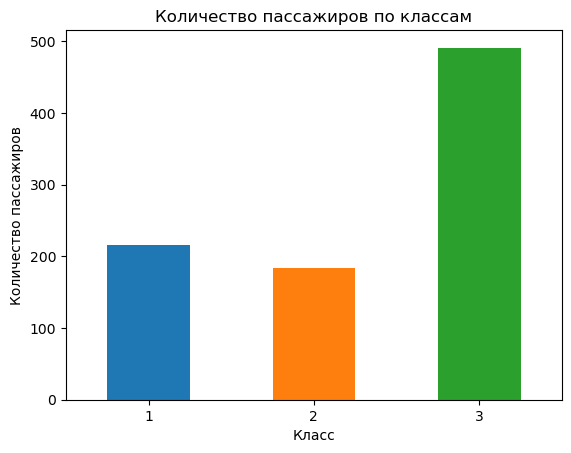

In [43]:
# График количества пассажиров по классам
df['Pclass'].value_counts().sort_index().plot(kind='bar', color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title('Количество пассажиров по классам')
plt.xlabel('Класс')
plt.ylabel('Количество пассажиров')
plt.xticks(rotation=0)
plt.show()


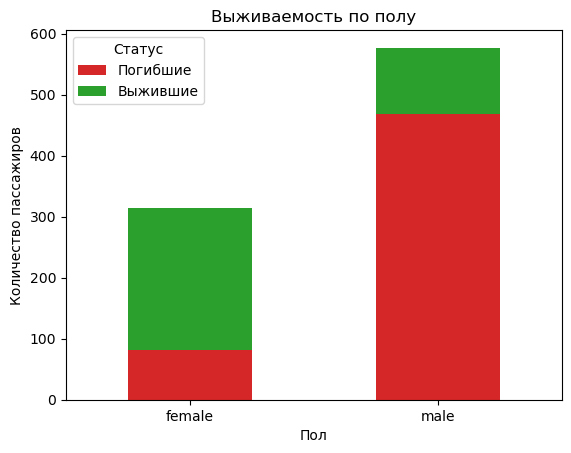

In [44]:
# График выживаемости по полу
surv_sex_plot = df.groupby(['Sex', 'Survived']).size().unstack()
surv_sex_plot.columns = ['Погибшие', 'Выжившие']
surv_sex_plot.plot(kind='bar', stacked=True, color=['#d62728', '#2ca02c'])
plt.title('Выживаемость по полу')
plt.xlabel('Пол')
plt.ylabel('Количество пассажиров')
plt.xticks(rotation=0)
plt.legend(title='Статус')
plt.show()


Собственный вопрос и ответ

In [45]:

# Вопрос: влияет ли наличие родственников на борту на выживаемость?
# Объединим SibSp и Parch в общий признак "кол-во родственников"
df['FamilySize'] = df['SibSp'] + df['Parch']

# Разделим на тех, кто был один, и тех, кто с родственниками
df['HasFamily'] = np.where(df['FamilySize'] > 0, 'С родственниками', 'Один')

family_surv = df.groupby('HasFamily')['Survived'].agg(['sum', 'count'])
family_surv['доля выживших'] = family_surv['sum'] / family_surv['count']
print("Выживаемость: один vs с родственниками:")
print(family_surv)

Выживаемость: один vs с родственниками:
                  sum  count  доля выживших
HasFamily                                  
Один              163    537       0.303538
С родственниками  179    354       0.505650


Вывод: пассажиры с родственниками на борту имели более высокую долю выживших, чем те, кто путешествовал один.